#**How do we identify a molecule**


# **Goals of Today**


*   **Chemistry**: How do we represent chemical structures in computer?
*   **Computation**: Introduction to `RDkit`, a Python package for cheminformatics





#**0.Installations**

Before we proceed, let us first install the following packages:

*   `py3Dmol`
*   `RDkit`


In [1]:
# install conda
!pip install -q condacolab
import condacolab
condacolab.install()

⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:17
🔁 Restarting kernel...


In [1]:
# Install py3Dmol for visualization
!mamba install py3Dmol


Looking for: ['py3dmol']

[+] 0.0s
[+] 0.1s
conda-forge/linux-64  ⣾  
conda-forge/noarch    ⣾  [+] 0.2s
conda-forge/linux-64   1%
conda-forge/noarch     1%[+] 0.3s
conda-forge/linux-64   2%
conda-forge/noarch    21%[+] 0.4s
conda-forge/linux-64   9%
conda-forge/noarch    40%[+] 0.5s
conda-forge/linux-64  18%
conda-forge/noarch    49%[+] 0.6s
conda-forge/linux-64  21%
conda-forge/noarch    63%[+] 0.7s
conda-forge/linux-64  26%
conda-forge/noarch    74%[+] 0.8s
conda-forge/linux-64  29%
conda-forge/noarch    85%[+] 0.9s
conda-forge/linux-64  34%
conda-forge/noarch    98%conda-forge/noarch                                
[+] 1.0s
conda-forge/linux-64  43%[+] 1.1s
conda-forge/linux-64  54%[+] 1.2s
conda-forge/linux-64  62%[+] 1.3s
conda-forge/linux-64  71%[+] 1.4s
conda-forge/linux-64  74%[+] 1.5s
conda-forge/linux-64  74%[+] 1.6s
conda-forge/linux-64  74%[+] 1.7s
conda-forge/linux-64  74%[+] 1.8s
conda-forge/linux-64  74%[+] 1.9s
conda-forge/linux-64  74%[+] 2.0s
conda-forge/linux-64  74

In [2]:
# Install rdkit
!mamba install rdkit


Looking for: ['rdkit']

conda-forge/linux-64                                        Using cache
conda-forge/noarch                                          Using cache

Pinned packages:
  - python 3.11.*
  - python 3.11.*
  - python_abi 3.11.* *cp311*
  - cuda-version 12.*


Transaction

  Prefix: /usr/local

  Updating specs:

   - rdkit
   - ca-certificates
   - certifi
   - openssl


  Package                          Version  Build                 Channel           Size
──────────────────────────────────────────────────────────────────────────────────────────
  Install:
──────────────────────────────────────────────────────────────────────────────────────────

  + icu                               75.1  he02047a_0            conda-forge       12MB
  + libwebp-base                     1.5.0  h851e524_0            conda-forge      430kB
  + pixman                          0.44.2  h29eaf8c_0            conda-forge      381kB
  + libjpeg-turbo                    3.0.0  hd590300_1     

#**1. Introduction: Chemical databases and chemical identification**

There are just too many molecules out there, and because of that, chemists have organize the information of molecules into databases. We can use these databases to identify and search for compounds, develop new drugs, create new synthesis routes, regulate chemical safety, and so on.

**Chemoinformatics** is the field that provides computer methods for learning from chemical data and for modeling tasks.

But, before we get into cheminformatics, we have to be able to represent chemicals using information. How would a chemists represent a molecule in a computer?

#**2.Chemical File Formats**


Are you feeling that you need some caffeine to stay away after lunch? Since most of us wants some caffeine, let's try to get some. But, how do we say caffeine in chemistry?


<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/8/8c/Caffeine_structure.svg/1920px-Caffeine_structure.svg.png" width="300">

##**2.1 XYZ**

The XYZ file format (extension `.xyz`) is a simple method for specifying the geometry of a molecule or collection of atoms. The basis format consists of:


1.   A header line giving the number of atoms, $n$;
2.   Another header line (which may be blank) containing a title, filename, or comments;
3. $n$ lines with at least four columns giving each atom's position, consisting of the element symbol and three-dimensional atomic coordinates, in Å.  



For Caffeine, this is what the XYZ file looks like:



```
24
Caffeine
H      -3.3804130    -1.1272367     0.5733036
N       0.9668296    -1.0737425    -0.8198227
C       0.0567293     0.8527195     0.3923156
N      -1.3751742    -1.0212243    -0.0570552
C      -1.2615018     0.2590713     0.5234135
C      -0.3068337    -1.6836331    -0.7169344
C       1.1394235     0.1874122    -0.2700900
N       0.5602627     2.0839095     0.8251589
O      -0.4926797    -2.8180554    -1.2094732
C      -2.6328073    -1.7303959    -0.0060953
O      -2.2301338     0.7988624     1.0899730
H       2.5496990     2.9734977     0.6229590
C       2.0527432    -1.7360887    -1.4931279
H      -2.4807715    -2.7269528     0.4882631
H      -3.0089039    -1.9025254    -1.0498023
H       2.9176101    -1.8481516    -0.7857866
H       2.3787863    -1.1211917    -2.3743655
H       1.7189877    -2.7489920    -1.8439205
C      -0.1518450     3.0970046     1.5348347
C       1.8934096     2.1181245     0.4193193
N       2.2861252     0.9968439    -0.2440298
H      -0.1687028     4.0436553     0.9301094
H       0.3535322     3.2979060     2.5177747
H      -1.2074498     2.7537592     1.7203047
```



**Demonstration: Writing an XYZ file and visualizing the molecule**



In [3]:
# Writing an XYZ file for caffeine

f = open("caffeine.xyz", "w")
f.write("""24
Caffeine
H      -3.3804130    -1.1272367     0.5733036
N       0.9668296    -1.0737425    -0.8198227
C       0.0567293     0.8527195     0.3923156
N      -1.3751742    -1.0212243    -0.0570552
C      -1.2615018     0.2590713     0.5234135
C      -0.3068337    -1.6836331    -0.7169344
C       1.1394235     0.1874122    -0.2700900
N       0.5602627     2.0839095     0.8251589
O      -0.4926797    -2.8180554    -1.2094732
C      -2.6328073    -1.7303959    -0.0060953
O      -2.2301338     0.7988624     1.0899730
H       2.5496990     2.9734977     0.6229590
C       2.0527432    -1.7360887    -1.4931279
H      -2.4807715    -2.7269528     0.4882631
H      -3.0089039    -1.9025254    -1.0498023
H       2.9176101    -1.8481516    -0.7857866
H       2.3787863    -1.1211917    -2.3743655
H       1.7189877    -2.7489920    -1.8439205
C      -0.1518450     3.0970046     1.5348347
C       1.8934096     2.1181245     0.4193193
N       2.2861252     0.9968439    -0.2440298
H      -0.1687028     4.0436553     0.9301094
H       0.3535322     3.2979060     2.5177747
H      -1.2074498     2.7537592     1.7203047""")

f.close()

Let's see if the file is in our folder, and let's print it out to make sure.

In [4]:
!ls

caffeine.xyz  condacolab_install.log  sample_data


In [ ]:
!cat caffeine.xyz

24
Caffeine
H      -3.3804130    -1.1272367     0.5733036
N       0.9668296    -1.0737425    -0.8198227
C       0.0567293     0.8527195     0.3923156
N      -1.3751742    -1.0212243    -0.0570552
C      -1.2615018     0.2590713     0.5234135
C      -0.3068337    -1.6836331    -0.7169344
C       1.1394235     0.1874122    -0.2700900
N       0.5602627     2.0839095     0.8251589
O      -0.4926797    -2.8180554    -1.2094732
C      -2.6328073    -1.7303959    -0.0060953
O      -2.2301338     0.7988624     1.0899730
H       2.5496990     2.9734977     0.6229590
C       2.0527432    -1.7360887    -1.4931279
H      -2.4807715    -2.7269528     0.4882631
H      -3.0089039    -1.9025254    -1.0498023
H       2.9176101    -1.8481516    -0.7857866
H       2.3787863    -1.1211917    -2.3743655
H       1.7189877    -2.7489920    -1.8439205
C      -0.1518450     3.0970046     1.5348347
C       1.8934096     2.1181245     0.4193193
N       2.2861252     0.9968439    -0.2440298
H      -0.1687028     

In the `RDkit` package, we can use the XYZ file to define the molecule. Let's give that a try.

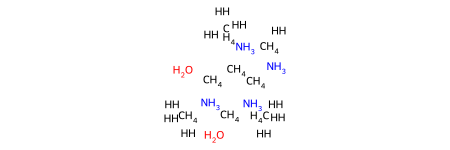

In [5]:
from rdkit import Chem

mol = Chem.MolFromXYZFile("caffeine.xyz")
mol # print the molecule

Oh no, it does not look like caffeine at all! It has a lot more hydrogens, and it does not know where the bonds are. This points to two issues in specifying chemical structures:


1.   In general, hydrogen atoms can often be deduced, so we often do now write them down
2.   The coordinates do not contain bond information





For now, we can fix the connectivity in the xyz file by recalculating the bonds and the number of hydrogens.

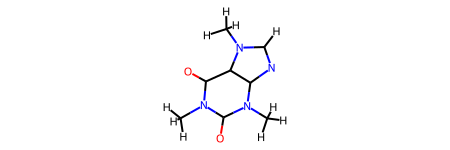

In [6]:
from rdkit.Chem import rdDetermineBonds

mol = Chem.MolFromXYZFile("caffeine.xyz")
conn_mol = Chem.Mol(mol)
rdDetermineBonds.DetermineConnectivity(conn_mol)
conn_mol

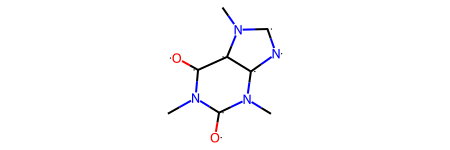

In [11]:
# We can also remove the hydrogen to make caffeine look better
conn_mol = Chem.RemoveHs(conn_mol)
conn_mol

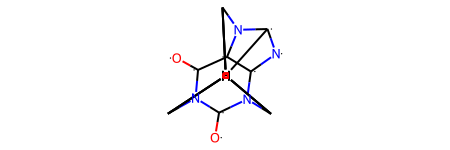

In [8]:
# Or, we can add the H back
conn_mol = Chem.AddHs(conn_mol)
conn_mol

In [12]:
import py3Dmol

p = py3Dmol.view(
    data=Chem.MolToMolBlock(conn_mol),  # Convert the RDKit molecule for py3Dmol
    style={'stick': {'radius': .1}, 'sphere': {'scale': 0.25}}
)
p.setBackgroundColor("0xeeeeee")
p.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

##**2.2 SMILES**

Since we can often deduce the number of hydrogens, the bond lengths, and bond angles, what is the most economical way of storing a chemical structure in the computer? One way to do so is using SMILES, which stands for the **Simplfied Molecular-Input Line-Entry System**. It represents chemical structures as short, plain text strings.

It is one of the most common method to represent molecules because of its simplicity and readability to the human eye.

Here are some examples of SMILES string:

```
Propane: CCC
Butane:  CCCC
Ethene:  C=C

```

Let's look at [some examples](https://docs.google.com/presentation/d/14U-LtCQ4-CAZ95Kdy-LubcllJ8VncwBGbaPvQYmjxlc/edit?usp=sharing) and try to figure out how SMILES represent molecules!

**In-class exercise: Caffeine's SMILES**

Do you feel like getting some caffeine now? Let's try to get some by writing down its SMILES string!

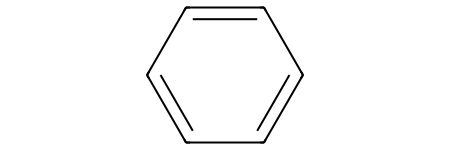

In [ ]:
# Getting a molecule from SMILES
# Example: Benzene. Change into caffeine instead
mol = Chem.MolFromSmiles("c1ccccc1")
mol

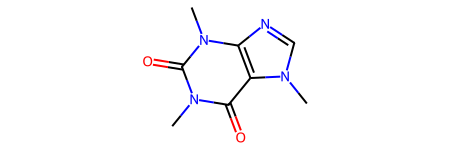

In [ ]:
# [Solution]
mol = Chem.MolFromSmiles('Cn1cnc2c1c(=O)n(C)c(=O)n2C')
mol

##**2.3 Molfile**

The widely used MDL Molfile format was created to describe the bonds, connectivity and coordinates of the atoms in a molecule. As with the SMILES format, hydrogen atoms can be assumed if not explicitly listed. It is a plain-text format, consisting of blocks of data encoding the molecular properties.



The Molfile has the following general structure:

![](https://premetabo.webservice.bmdrc.org/wp-content/uploads/sites/3/2015/01/molsdf1.gif)




Caffeine time again! Let's write a Molfile and see what it looks like:

In [13]:
# script to write a mol file for caffeine
f = open("caffeine.mol", "w")
f.write("""2519
  -OEChem-02252517363D

 24 25  0     0  0  0  0  0  0999 V2000
    0.4700    2.5688    0.0006 O   0  0  0  0  0  0  0  0  0  0  0  0
   -3.1271   -0.4436   -0.0003 O   0  0  0  0  0  0  0  0  0  0  0  0
   -0.9686   -1.3125    0.0000 N   0  0  0  0  0  0  0  0  0  0  0  0
    2.2182    0.1412   -0.0003 N   0  0  0  0  0  0  0  0  0  0  0  0
   -1.3477    1.0797   -0.0001 N   0  0  0  0  0  0  0  0  0  0  0  0
    1.4119   -1.9372    0.0002 N   0  0  0  0  0  0  0  0  0  0  0  0
    0.8579    0.2592   -0.0008 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.3897   -1.0264   -0.0004 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.0307    1.4220   -0.0006 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.9061   -0.2495   -0.0004 C   0  0  0  0  0  0  0  0  0  0  0  0
    2.5032   -1.1998    0.0003 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.4276   -2.6960    0.0008 C   0  0  0  0  0  0  0  0  0  0  0  0
    3.1926    1.2061    0.0003 C   0  0  0  0  0  0  0  0  0  0  0  0
   -2.2969    2.1881    0.0007 C   0  0  0  0  0  0  0  0  0  0  0  0
    3.5163   -1.5787    0.0008 H   0  0  0  0  0  0  0  0  0  0  0  0
   -1.0451   -3.1973   -0.8937 H   0  0  0  0  0  0  0  0  0  0  0  0
   -2.5186   -2.7596    0.0011 H   0  0  0  0  0  0  0  0  0  0  0  0
   -1.0447   -3.1963    0.8957 H   0  0  0  0  0  0  0  0  0  0  0  0
    4.1992    0.7801    0.0002 H   0  0  0  0  0  0  0  0  0  0  0  0
    3.0468    1.8092   -0.8992 H   0  0  0  0  0  0  0  0  0  0  0  0
    3.0466    1.8083    0.9004 H   0  0  0  0  0  0  0  0  0  0  0  0
   -1.8087    3.1651   -0.0003 H   0  0  0  0  0  0  0  0  0  0  0  0
   -2.9322    2.1027    0.8881 H   0  0  0  0  0  0  0  0  0  0  0  0
   -2.9346    2.1021   -0.8849 H   0  0  0  0  0  0  0  0  0  0  0  0
  1  9  2  0  0  0  0
  2 10  2  0  0  0  0
  3  8  1  0  0  0  0
  3 10  1  0  0  0  0
  3 12  1  0  0  0  0
  4  7  1  0  0  0  0
  4 11  1  0  0  0  0
  4 13  1  0  0  0  0
  5  9  1  0  0  0  0
  5 10  1  0  0  0  0
  5 14  1  0  0  0  0
  6  8  1  0  0  0  0
  6 11  2  0  0  0  0
  7  8  2  0  0  0  0
  7  9  1  0  0  0  0
 11 15  1  0  0  0  0
 12 16  1  0  0  0  0
 12 17  1  0  0  0  0
 12 18  1  0  0  0  0
 13 19  1  0  0  0  0
 13 20  1  0  0  0  0
 13 21  1  0  0  0  0
 14 22  1  0  0  0  0
 14 23  1  0  0  0  0
 14 24  1  0  0  0  0
M  END""")

f.close()

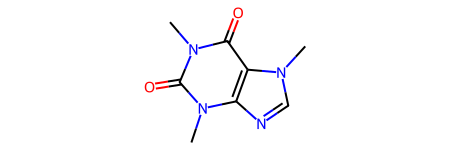

In [14]:
mol = Chem.MolFromMolFile("caffeine.mol")
mol

In [15]:
import py3Dmol

p = py3Dmol.view(
    data=Chem.MolToMolBlock(mol),  # Convert the RDKit molecule for py3Dmol
    style={'stick': {'radius': .1}, 'sphere': {'scale': 0.25}}
)
p.setBackgroundColor("0xeeeeee")
p.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
!cat caffeine.mol

2519
  -OEChem-02252517363D

 24 25  0     0  0  0  0  0  0999 V2000
    0.4700    2.5688    0.0006 O   0  0  0  0  0  0  0  0  0  0  0  0
   -3.1271   -0.4436   -0.0003 O   0  0  0  0  0  0  0  0  0  0  0  0
   -0.9686   -1.3125    0.0000 N   0  0  0  0  0  0  0  0  0  0  0  0
    2.2182    0.1412   -0.0003 N   0  0  0  0  0  0  0  0  0  0  0  0
   -1.3477    1.0797   -0.0001 N   0  0  0  0  0  0  0  0  0  0  0  0
    1.4119   -1.9372    0.0002 N   0  0  0  0  0  0  0  0  0  0  0  0
    0.8579    0.2592   -0.0008 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.3897   -1.0264   -0.0004 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.0307    1.4220   -0.0006 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.9061   -0.2495   -0.0004 C   0  0  0  0  0  0  0  0  0  0  0  0
    2.5032   -1.1998    0.0003 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.4276   -2.6960    0.0008 C   0  0  0  0  0  0  0  0  0  0  0  0
    3.1926    1.2061    0.0003 C   0  0  0  0  0  0  0  0  0  0  0  0
   -2.2969    2.1881 

## **2.4 International Chemical Identifier (InChI)**

The IUPAC International Chemical Identifier (InChI) was originally developed by the IUPAC and continuing development efforts have been made by the InChI Trust. InChI is non-proprietary, open-source, and freely available to the scientific community. Especially, because the software for generating InChI strings is also freely available, it avoids the interoperability issue that different implementations of SMILES language have.

InChI encodes a chemical structure into “layers”. Each layer holds a distinct and separable class of structural information, with the layers ordered to provide successive structural refinement. There are currently six InChI layer types, each different class of structural information: the main layer, a charge layer, a stereochemical layer, an isotopic layer, a fixed-H layer and a reconnected layer. The main layer, which specifies chemical formula, atoms, and bonds between them, is required for all InChIs. However, the other layers appear only when corresponding input information is provided. Layers and sublayers start with “/” (forward slash) followed by a letter denoting the identity of the layer (except for the chemical formula layer). Below are some examples of InChI.

    InChI=1S/CH4/h1H4 (methane)
    InChI=1S/C2H6/c1-2/h1-2H3 (ethane)
    InChI=1S/C2H6O/c1-2-3/h3H,2H2,1H3 (ethanol)
    InChI=1S/C3H7NO2/c1-2(4)3(5)6/h2H,4H2,1H3,(H,5,6)/t2-/m0/s1 (L-alanine)

These InChI strings are not easy for a human to understand (especially compared to SMILES strings). It is because InChI was developed as a “machine-readable” chemical identifier, with an aim to enable a computer to regenerate the corresponding chemical structure from the InChI string generated by another computer. For this reason, InChI is often called as the bar code for chemical structures.

Because the layered structure of InChI allows one to represent a chemical structure with a desired level of details, InChI software may generate different InChI strings for the same molecule. This flexibility may be regarded as an obstacle to standardization and interoperability. In response to this concern, the standard InChI was introduced which contains the same level of structural details and the same conventions for drawing perception, by using standard option settings in InChI software. The standard InChI representations begin with “InChI=1S/”, while the non-standard InChI begins with “InChI=1/”. The digit “1” following “InChI=” is the current InChI version number.

(Source: [ChemLibreText](https://chem.libretexts.org/Courses/University_of_Arkansas_Little_Rock/ChemInformatics_(2017)%3A_Chem_4399_5399/2.3%3A_Chemical_Representations_on_Computer%3A_Part_III))


Why do we need InChi? Watch this [video](https://youtu.be/qrCqJ0o4jGs?feature=shared)!

# **Debrief: What have we learned today?**

Let us reflect on what are the new skills we have learned today. We will classify the skills into chemical knowledge and computation skills.

**New chemical knowledge today:**

*   List response
*   List response

**New computational skill today:**

*   List response


## **How can I make the class better?**

Please let me know [here](https://docs.google.com/forms/d/e/1FAIpQLSd6iRTXWhMHmc0MqXXiAWdglDqEa0mKcXQRXm6LyD4HS-6v7g/viewform)!